# ___Phylogenetic traversal of independent ACEs of discrete and continuous traits___
---------------------------------------------------

In [ ]:
print(R.version$version.string)

In [41]:
library("ape")
library("phytools")
library("corHMM")
library("ggplot2")
library("lattice")
library("latex2exp")
library("dplyr")

source("../helpers.R")
source("../deltastatistic.R")

set.seed(2026 - 2 - 24)


Attaching package: 'dplyr'


The following object is masked from 'package:ggplot2':

    vars


The following object is masked from 'package:ape':

    where


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




## ___ACE of discrete categorical traits using `ape`, `corHMM` & `phytools`___
------------------------------------------------------

In [7]:
tm

Time difference of 12.70665 mins

In [35]:
#-----------------------------
# USE THE SAVED MODELS
#-----------------------------

load("../rdata/statesARD.RData")

In [36]:
head(ace_mystates_ape$lik.anc) # ACEs from ape::ace

,AM,AMEcM,AMNM,EcM,ErM,NM
,0.1780128,0.1676519782,0.1678403036,1.578790e-01,0.1634351304,0.1651807701
Spermatophyta,0.6310866,0.0084835214,0.0046855818,3.366856e-01,0.0104656214,0.0085930809
Mesangiospermae,0.9977981,0.0008962305,0.0007030107,4.117119e-05,0.0001865737,0.0003748925
mrcaott2ott121,0.9976927,0.0009171114,0.0008248579,5.346829e-06,0.0001821443,0.0003778518
eudicotyledons,0.9955822,0.0018531260,0.0015132375,1.289059e-04,0.0003336385,0.0005888917
mrcaott2ott969,0.9940667,0.0023077572,0.0023268170,7.445513e-05,0.0004406938,0.0007835858


In [37]:
head(ace_mystates_ancr$ace) # ACEs from phytools::ancr

,AM,AMEcM,AMNM,EcM,ErM,NM
396,0.0922244,5.397558e-05,4.223003e-01,6.549021e-04,0,4.847664e-01
397,0.5235107,7.513800e-05,2.002798e-01,6.545492e-04,0,2.754798e-01
398,0.9998722,3.853322e-14,7.447998e-05,1.675982e-08,0,5.331681e-05
399,0.9998850,1.748693e-12,6.994310e-05,6.788944e-09,0,4.503764e-05
400,0.9997399,1.083204e-11,2.386851e-04,2.615169e-08,0,2.134789e-05
401,0.9998144,1.764122e-10,1.683307e-04,6.426645e-08,0,1.716133e-05


In [38]:
head(ace_mystates_hmm$states) # ACEs from corHMM

"(1,R1)","(2,R1)","(3,R1)","(4,R1)","(5,R1)","(6,R1)"
0.7384633,1.040288e-04,0.0994976039,6.260653e-03,6.030534e-04,1.550713e-01
0.8501157,7.903288e-04,0.0747048386,5.612279e-03,2.847190e-05,6.874840e-02
0.9991916,9.818027e-13,0.0008082208,7.337873e-08,1.788241e-15,1.214591e-07
0.9992163,2.685532e-11,0.0007836026,3.027913e-08,2.436969e-14,8.614221e-08
0.9989217,2.534694e-10,0.0010780045,5.338445e-08,3.126602e-12,2.003021e-07
0.9990869,3.113141e-09,0.0009128237,1.242300e-07,2.405557e-12,1.708078e-07


In [39]:
# the output of corHMM lacks explicit column names (mycorrhizal states)
# outputs of ape and corHMM lack explicit row names (node numbers)

## ___Manual phylogeny traversal using presaved ACEs of discrete trait___
---------------------------

In [40]:
ace_mystates_hmm


Fit
      -lnL      AIC     AICc Rate.cat ntax
 -127.3412 314.6825 319.7924        1  395

Legend
      1       2       3       4       5       6 
   "AM" "AMEcM"  "AMNM"   "EcM"   "ErM"    "NM" 

Rates
            (1,R1)       (2,R1)       (3,R1)      (4,R1)       (5,R1)
(1,R1)          NA 0.0003220296 0.0009737899 0.000201527 6.729156e-05
(2,R1) 0.000000001           NA 0.0000000010 0.017445718 1.000000e-09
(3,R1) 0.016863141 0.0000000010           NA 0.000000001 1.000000e-09
(4,R1) 0.001299564 0.0000000010 0.0000000010          NA 1.000000e-09
(5,R1) 0.000000001 0.0000000010 0.0000000010 0.000000001           NA
(6,R1) 0.000000001 0.0000000010 0.0071694536 0.000000001 1.000000e-09
             (6,R1)
(1,R1) 1.000000e-09
(2,R1) 1.000000e-09
(3,R1) 1.027515e-02
(4,R1) 1.000039e-09
(5,R1) 9.735390e-04
(6,R1)           NA

Arrived at a reliable solution 

In [41]:
# based on the legend of the corHMM model output
STATES_LEGEND_CORHMM <- c("AM", "AMEcM", "AMNM", "EcM", "ErM", "NM")
STATES_LEGEND_CORHMM

[1] "AM"    "AMEcM" "AMNM"  "EcM"   "ErM"   "NM"

In [42]:
state_preds_hmm <- STATES_LEGEND_CORHMM[apply(ace_mystates_hmm$states, MARGIN = 1, FUN = which.max)] # MARGIN = 1 is used for row wise apply

# colnames(ace_mystates_ancr$ace)
state_preds_phy <- colnames(ace_mystates_ancr$ace)[apply(ace_mystates_ancr$ace, MARGIN = 1, FUN = which.max)] # only the output of phytools::ancr has explicit node numbers as row names!!

# colnames(ace_mystates_ape$lik.anc)
state_preds_ape <- colnames(ace_mystates_ape$lik.anc)[apply(ace_mystates_ape$lik.anc, MARGIN = 1, FUN = which.max)]

In [43]:
mean(state_preds_ape == state_preds_hmm)

[1] 0.9720812

In [44]:
mean(state_preds_ape == state_preds_phy) # the lowest

[1] 0.9492386

In [45]:
mean(state_preds_phy == state_preds_hmm) # the highest

[1] 0.9771574

In [46]:
all(rownames(ace_mystates_ancr$ace) == 396:789) # internal node names

[1] TRUE

In [33]:
#--------------------------------
# ACE OF CONTINUOUS TRAITS
#--------------------------------

ace_srl_fastanc <- phytools::fastAnc(tree = PHYLOGENY, x = SRL, vars = TRUE, CI = TRUE) # this is a Maximim Likelihood (ML) based method - Brownian motion models which essentially is a Markov process on a continuous scale
# https://eeob-macroevolution.github.io/Practicals/Ancestral_State_Estimation/AncStateEstimation_Tutorial.html
# the link above provides detailed info on ACE, and also recommends incorporating fossil data when available to make the ACE more rigorous
# do we have fossil root trait data???????

# Liam J. Revell's website says that phytools::fastAnc also uses Felsenstein's re-rooting algorithm for ACE of continuous characters - http://www.phytools.org/Cordoba2017/ex/7/Anc-states-continuous.html
# PCMIR (page 224) recommends fitting phytools::fastAnc with vars=TRUE, CI=TRUE as ACE happens with lots of uncertainty, so it's important to know the CIs of each reconstruction
ace_rd_fastanc <- phytools::fastAnc(tree = PHYLOGENY, x = RD, vars = TRUE, CI = TRUE) # repeat the above for RD

ERROR: Error: object 'PHYLOGENY' not found


In [28]:
# examine the variances and confidence intervals of the ACE of the continuous trait
head(ace_srl_fastanc$CI95)

396,-521.88296,696.2604
397,-469.20576,617.9810
398,-95.15662,268.0453
399,-94.00978,267.6452
400,-81.94660,263.1486
401,-79.43571,260.9921


In [30]:
# see if the ACEs fall within the respective 95% CIs (BUT THESE 95% CIs ARE REALLY BROAD?????)
mean(ace_srl_fastanc$CI95[, 2] >= ace_srl_fastanc$ace) # estimates lesses than or equal to the upper bound
mean(ace_srl_fastanc$CI95[, 1] <= ace_srl_fastanc$ace) # estimates greater than or equal to the lower bound

[1] 1

[1] 1

In [31]:
# check the 95% CIs for RD
mean(ace_rd_fastanc$CI95[, 1] <= ace_rd_fastanc$ace) # lower bound <= ACE
mean(ace_rd_fastanc$CI95[, 2] >= ace_rd_fastanc$ace) # upper bound >= ACE

[1] 1

[1] 1

In [34]:
# the plan here is to find out the (2) nodes at each branch of the phylogeny and capture and store the changes in SRL and mycorrhizal states corresponding to the branches
# we can start this with the internodes as the tips can only be at the descendent end of a branch, never at an ancestor end

## ___Collab subset with 995 species averages (genus level mycorrhizal state recommendations from FungalRoot)___
---------------------------------

## $\delta{t}=log(t_{ancestor})-log(t_{descendant})$

In [6]:
traitdata <- read.csv("../../data/chapter2/FREDv3subset/collab_fineroots_log_995_species_means_5states.csv", stringsAsFactors = TRUE) # LOG TRANSFORMED CONTINUOUS TRAIT VALUES
phylogeny <- ape::multi2di(ape::read.tree("../../data/chapter2/uphylomaker/collab_fineroots_log_995_species_means_5states.tre"))
traitdata <- traitdata[match(phylogeny$tip.label, traitdata$binominal), ]

stopifnot(traitdata$binominal == phylogeny$tip.label)

In [7]:
traitdata[, c("binominal", "state")] |> head()

,binominal,state
,<fct>,<fct>
826,Rudbeckia_hirta,AM
802,Ratibida_pinnata,AM
468,Heliopsis_helianthoides,NM
526,Liatris_aspera,AM
104,Arnica_sororia,AM
103,Arnica_fulgens,AM


In [13]:
table(traitdata$state) # mycorrhizal state diversity


   AM   EcM EcMAM    NM  NMAM 
  778   122    26    20    49 

In [96]:
#---------------------------------------------------------------------------------------------------------------------
# bofore that test for phylogenetic signal in continuous traits using Bloombergs K test and Pagel's lambda test
#---------------------------------------------------------------------------------------------------------------------

In [97]:
# in Bloomberg's K test, phylogenetic signal is considered high when variance between clades is lesser than the variance within clades
# K = 1.000 indicates Brownian motion based evolution

In [19]:
# do we see a phylogenetic signal???
bberg_rd <- phytools::phylosig(tree = phylogeny, x = setNames(traitdata$F00679, nm = traitdata$binominal), test = TRUE, nsim = 10000)
bberg_rd


Phylogenetic signal K : 0.0293936 
P-value (based on 10000 randomizations) : 1e-04 


In [33]:
bberg_srl <- phytools::phylosig(tree = phylogeny, x = setNames(traitdata$F00727, nm = traitdata$binominal), test = TRUE, nsim = 10000)
bberg_srl


Phylogenetic signal K : 0.0241411 
P-value (based on 10000 randomizations) : 3e-04 


In [34]:
png("../../plots/BloombergsKRD99.png", width = 1000, height = 1000, units = "px")
plot(bberg_rd)
dev.off()

png("../../plots/BloombergsKSRL99.png", width = 1000, height = 1000, units = "px")
plot(bberg_srl)
dev.off()

pdf 
  2

pdf 
  2

In [105]:
# now using Pagel's lambda tests
# lambda < 1 means that less phylogenetic signal than expected under a Brownian motion model of evolution

pagels_rd <- phytools::phylosig(tree = phylogeny, x = setNames(rd1005$RD, nm = rd1005$binominal), method = "lambda", test = TRUE)
pagels_rd


Phylogenetic signal lambda : 0.764027 
logL(lambda) : -548.524 
LR(lambda=0) : 228.76 
P-value (based on LR test) : 1.11121e-51 


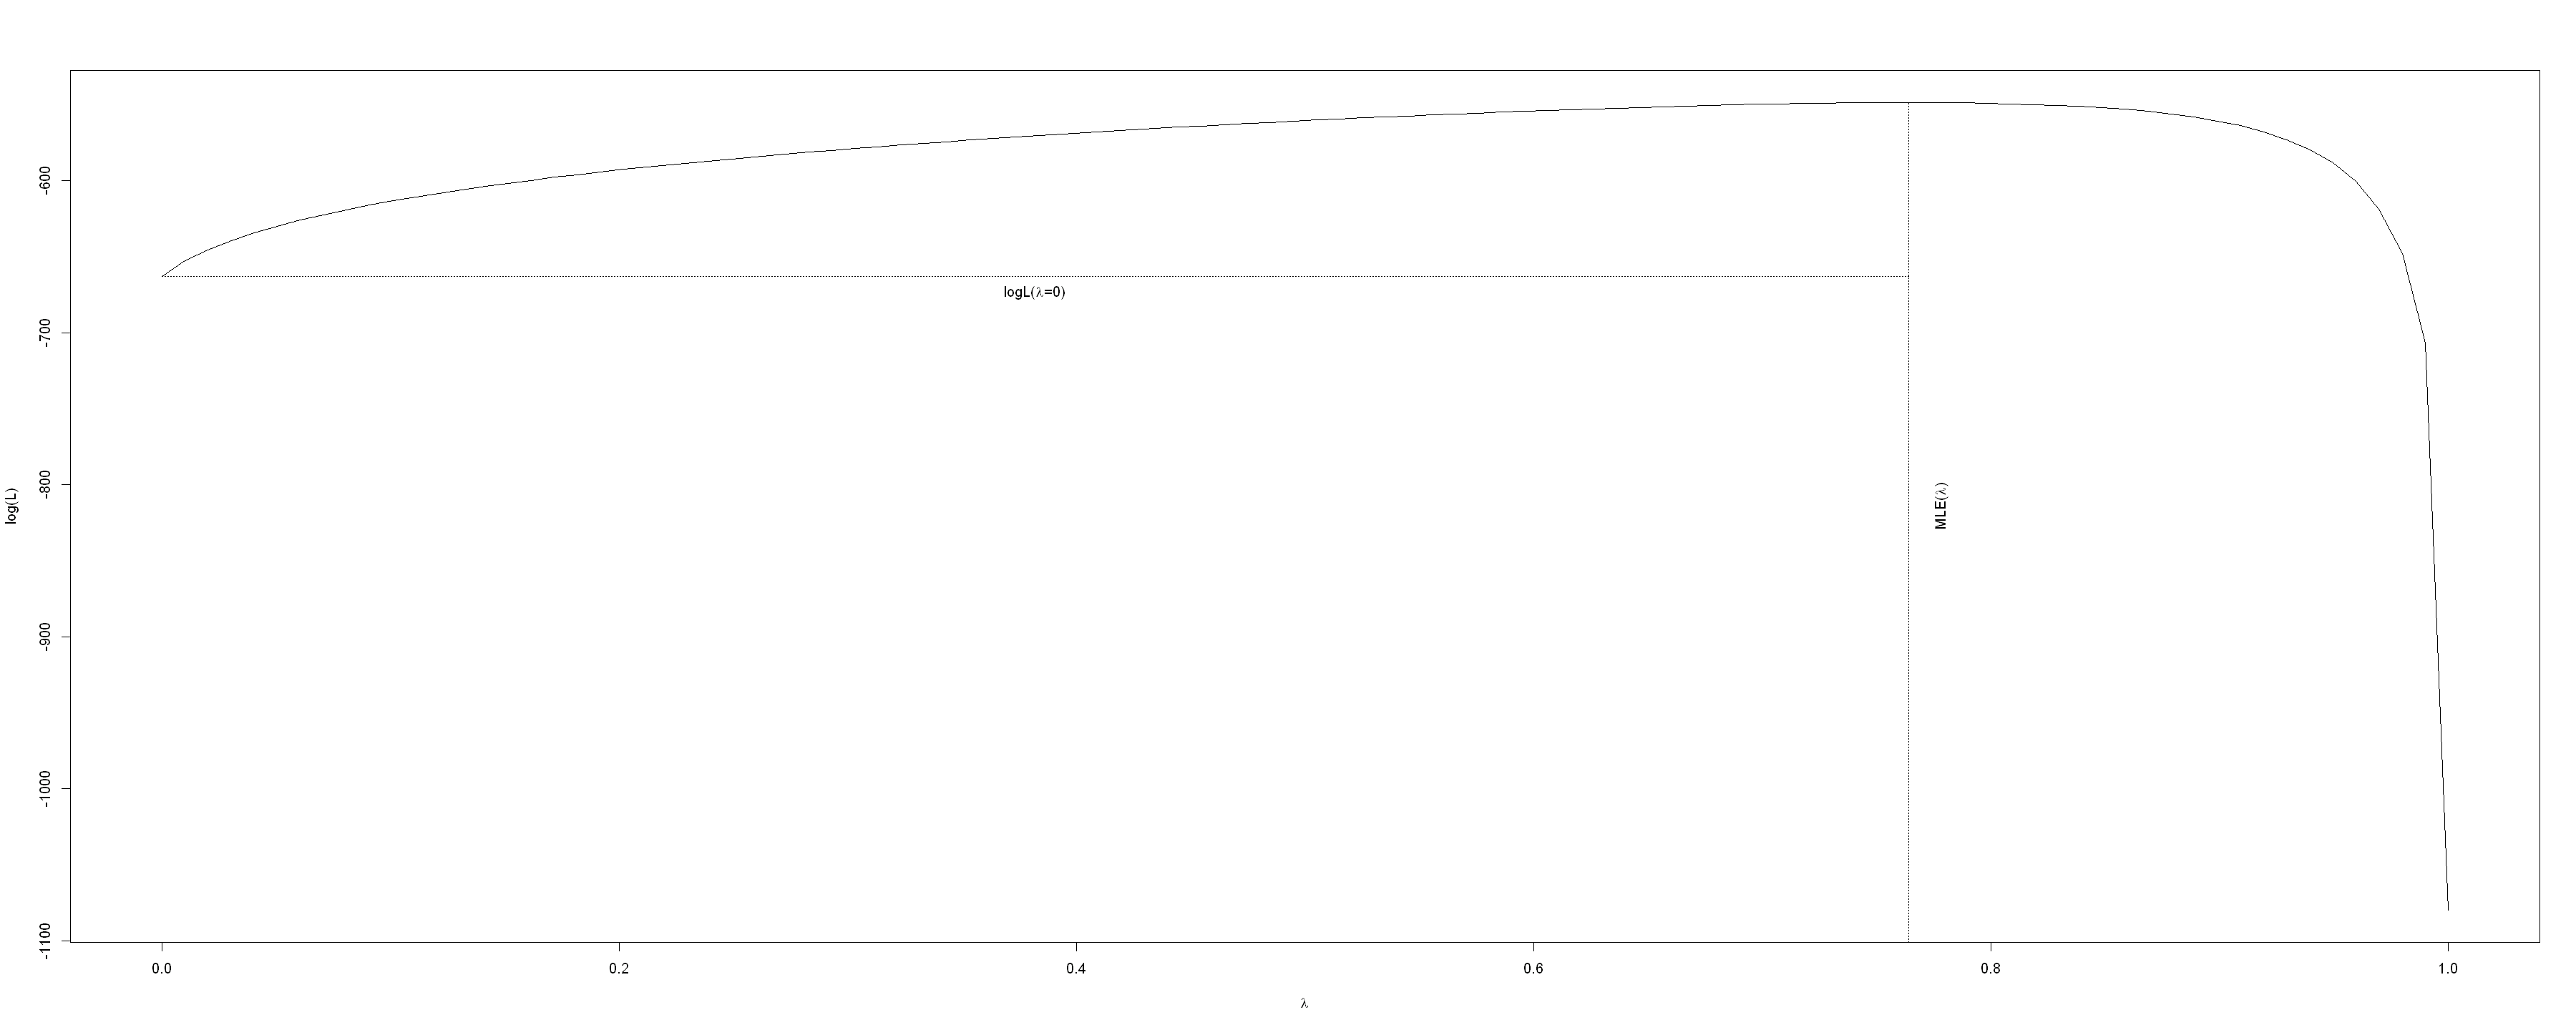

In [106]:
plot(pagels_rd)

In [107]:
pagels_srl <- phytools::phylosig(tree = phylogeny, x = setNames(srl1005$SRL, nm = srl1005$binominal), method = "lambda", test = TRUE)
pagels_srl


Phylogenetic signal lambda : 0.699249 
logL(lambda) : -1480.39 
LR(lambda=0) : 207.026 
P-value (based on LR test) : 6.11896e-47 


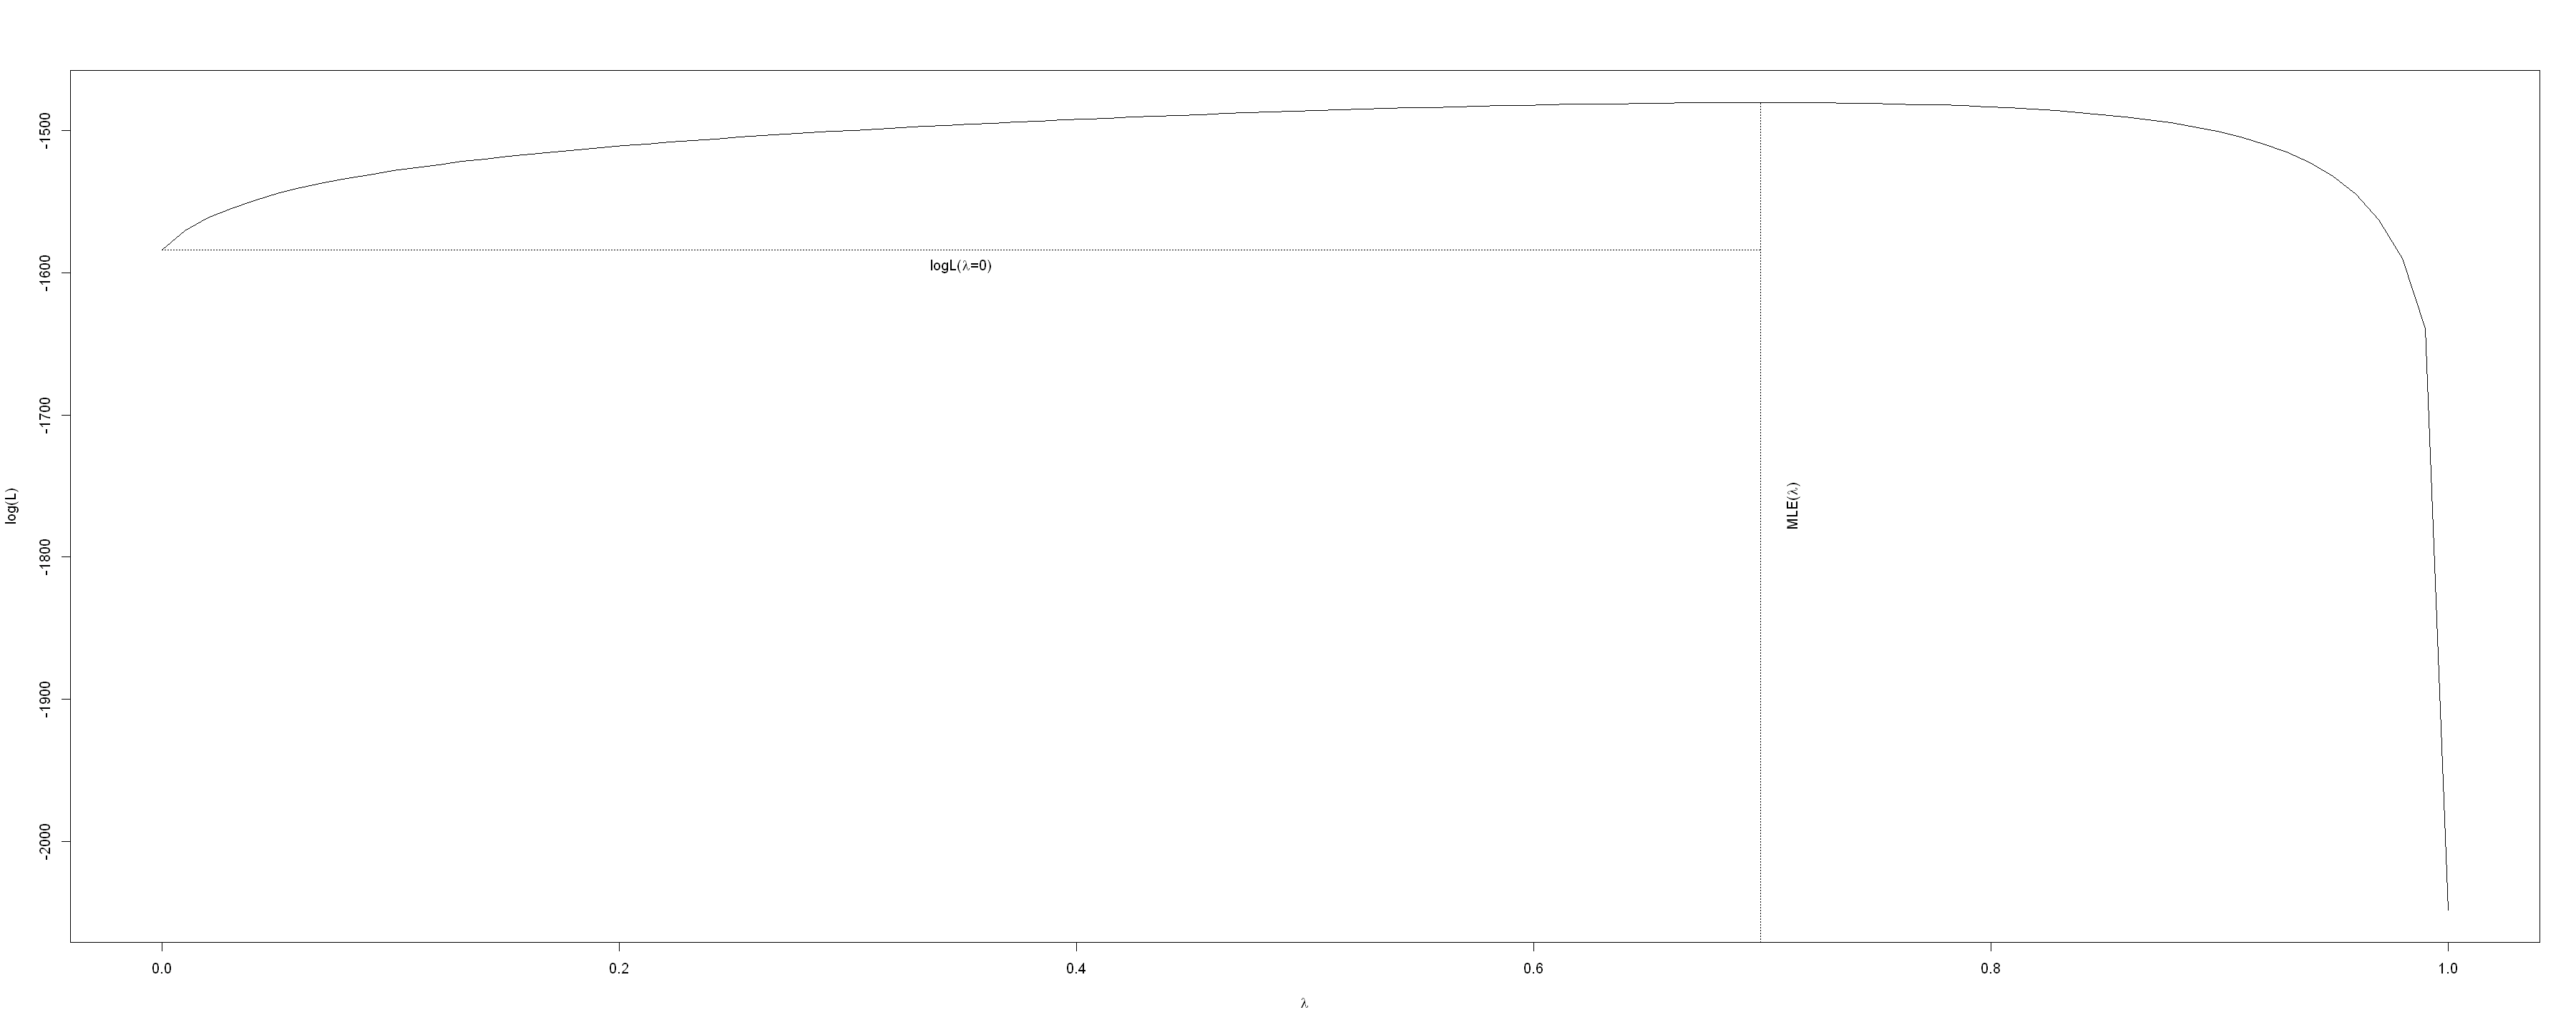

In [108]:
plot(pagels_srl)

In [10]:
# phylogenetic signal in the discrete trait

phylogeny_delta <- phylogeny # this method requires modofications to the phylogeny, hence making a copy

# it is important to guarantee that all the branches are positive as this method requires a metric-tree (i.e., branch_lengths > 0). i.e cannot have polytomies???
# here, we take 1% of the 1% quantile to fill in the null branches
phylogeny_delta$edge.length[phylogeny_delta$edge.length==0] <- quantile(phylogeny_delta$edge.length, 0.1) * 0.1 # update the 0 length branches with the said value

# we need to define the trait vector. confirm that the trait order follows the species order in the tree
statevec <- setNames(traitdata$state, nm = traitdata$binominal)

deltastat <- 0.000

withCallingHandlers(
      warning = function(condition) {
                    invokeRestart(r="muffleWarning")
      },
      # spits out so many warning lines w/o the warning handler
      deltastat <<- delta(trait = statevec, tree = phylogeny_delta, lambda0 = 0.1, se = 0.05, sim = 10000, thin = 1, burn = 1) # read the source to see what these args mean!!!!!
)

# choosing to keep all the iterations

In [11]:
deltastat

[1] 7.652617

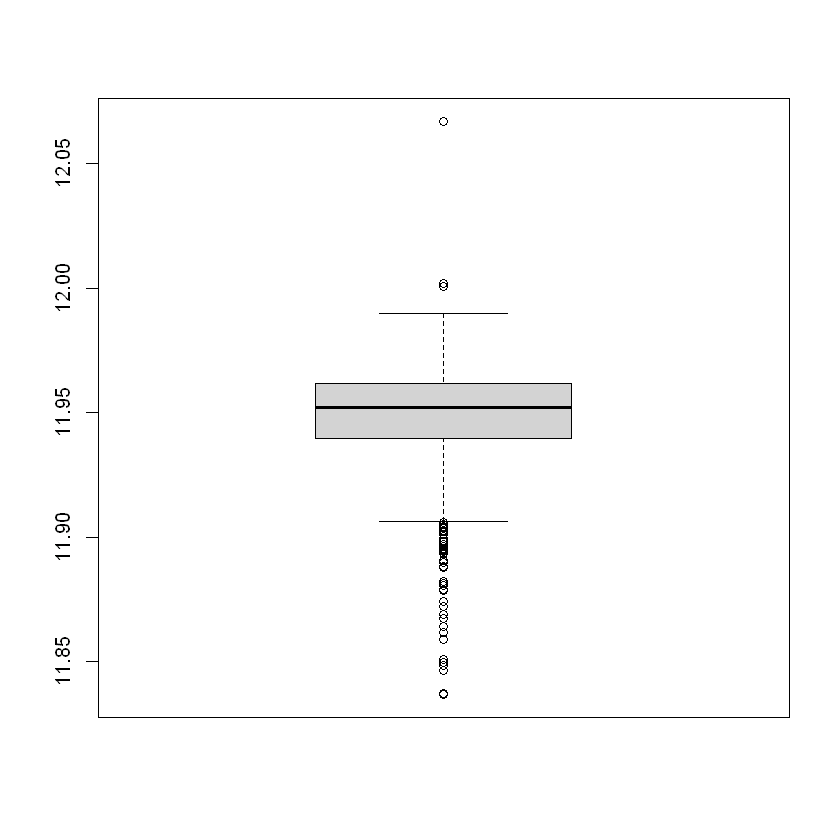

In [12]:
# compute the p value using simulation
NITERATIONS <- 1000
random_delta <- rep(NA, NITERATIONS)

for (i in 1:NITERATIONS){
  rtrait <- sample(statevec) # suffles the trait vector while keeping the size
  withCallingHandlers(
      warning = function(condition) {
                    invokeRestart(r="muffleWarning")
      },
      random_delta[i] <<- delta(rtrait, phylogeny, lambda0 = 0.1, se = 0.05, sim = 1000, thin = 1, burn = 1)
  )
}

p_value <- sum(random_delta>deltastat) / NITERATIONS

In [34]:
mean(random_delta > deltastat) # tf????

[1] 1

ERROR: Error in UseMethod("xyplot"): no applicable method for 'xyplot' applied to an object of class "c('double', 'numeric')"


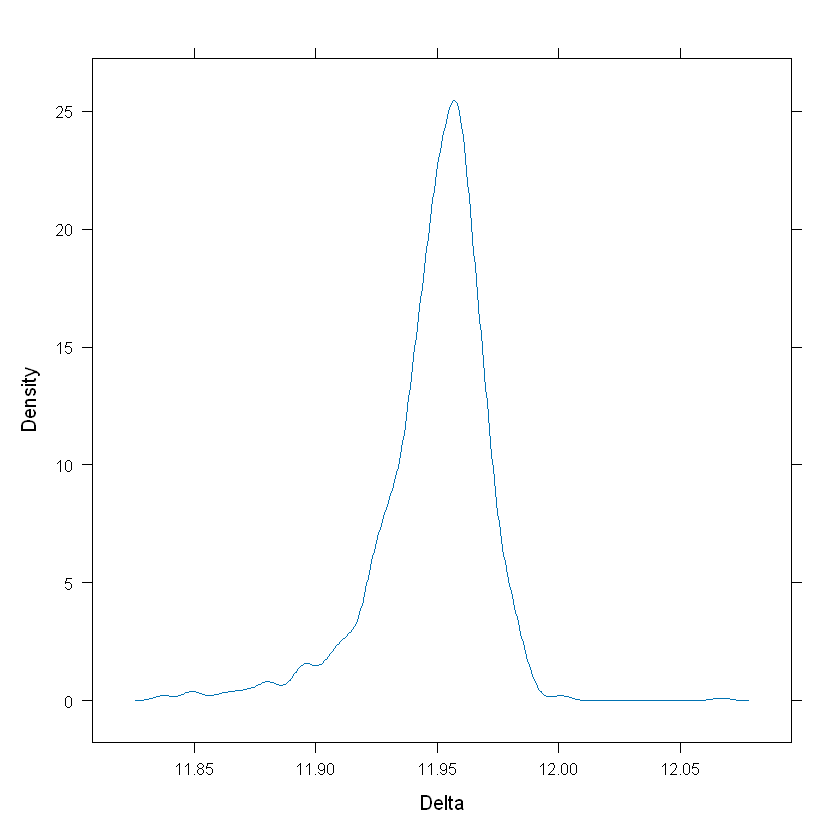

In [47]:
densityplot(random_delta, xlab = "Delta", plot.points = FALSE)

In [3]:
load("../rdata/IndependentACEs995sp5statesLog.RData") # ACES of continuous traits were done using log transformed trait values (RD, SRL)

In [4]:
# compare the discrete ACEs
# all ACE tables have columns in the following order => # AM	EcM	EcMAM	NM	NMAM

mean(apply(ace_5states_995_ape$lik.anc, MARGIN = 1, FUN = which.max)  == apply(ace_5states_995_corhmm$states, MARGIN = 1, FUN = which.max))
mean(apply(ace_5states_995_ape$lik.anc, MARGIN = 1, FUN = which.max)  == apply(ace_5states_995_phytools$ace, MARGIN = 1, FUN = which.max))
mean(apply(ace_5states_995_corhmm$states, MARGIN = 1, FUN = which.max) == apply(ace_5states_995_phytools$ace, MARGIN = 1, FUN = which.max))

[1] 0.9657948

[1] 0.9607646

[1] 0.9949698

In [5]:
phylogeny # has 994 internal nodes

ERROR: Error: object 'phylogeny' not found


In [8]:
ace_5states_995_corhmm


Fit
      -lnL      AIC     AICc Rate.cat ntax
 -221.4237 482.8474 483.7099        1  995

Legend
      1       2       3       4       5 
   "AM"   "EcM" "EcMAM"    "NM"  "NMAM" 

Rates
             (1,R1)       (2,R1)       (3,R1)       (4,R1)       (5,R1)
(1,R1)           NA 0.0002014373 0.0002166429 0.0002218101 0.0007887831
(2,R1) 0.0007754370           NA 0.0000000010 0.0000000010 0.0000000010
(3,R1) 0.0142979100 0.0000000010           NA 0.0000000010 0.0000000010
(4,R1) 0.0006245473 0.0000000010 0.0000000010           NA 0.0000000010
(5,R1) 0.0011455450 0.0007783447 0.0000000010 0.0000000010           NA

Arrived at a reliable solution 

In [9]:
CORHMM_5STATES_LEGEND <- c("AM", "EcM", "EcMAM", "NM", "NMAM")

In [10]:
paired_changes <- paired_dc_changes(phylogeny = phylogeny,
                                    rdextant = setNames(traitdata$F00679, nm = traitdata$binominal),
                                    srlextant = setNames(traitdata$F00727, nm = traitdata$binominal),
                                    discextant = setNames(traitdata$state, nm = traitdata$binominal),
                                    rdinternodes = ace_rd_995$ace,
                                    srlinternodes = ace_srl_995$ace,
                                    discprobinternodes = ace_5states_995_corhmm$states,
                                    discstates = CORHMM_5STATES_LEGEND)

In [11]:
head(paired_changes)

,shifts,delta_rd,delta_srl
,<chr>,<dbl>,<dbl>
1,AM_to_AM,0.002480619,0.006524816
2,AM_to_AM,-0.054448123,0.234665175
3,AM_to_AM,0.031589377,-0.056366143
4,AM_to_AM,0.003543559,-0.006095365
5,AM_to_AM,0.070699188,-0.072416572
6,AM_to_AM,0.020077742,-0.013665562


In [12]:
#----------------------------------------------------------------------
# CHANGES IN LOG RD WITH CORRESPONDING MYCORRHIZAL STATE TRANSITIONS
#----------------------------------------------------------------------

# the continuous trait change measured here is the (value of ancestor - value of descendant)
as.data.frame(lapply(split(paired_changes, ~shifts), FUN = function(df) { c(mean(df$delta_rd), sd(df$delta_rd)) }), row.names = c("mean", "std")) # summary

,AM_to_AM,AM_to_EcM,AM_to_EcMAM,AM_to_NM,AM_to_NMAM,EcM_to_AM,EcM_to_EcM,EcM_to_NMAM,EcMAM_to_AM,EcMAM_to_EcMAM,NM_to_NM,NMAM_to_AM,NMAM_to_EcM,NMAM_to_NMAM
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
mean,-0.00227363,0.001977551,-0.09102003,0.1945589,-0.009203943,0.00842402,0.001767719,0.3076190,0.1672044,0.0122208,0.009987086,-0.03364303,-0.28515146,0.01754058
std,0.24112662,0.277641482,0.37549041,0.3912832,0.301737926,NA,0.239752664,0.0653178,0.5360357,0.2559199,0.167460652,NA,0.07965926,0.27796834


In [21]:
#----------------------------------------------------------------------
# CHANGES IN LOG SRL WITH CORRESPONDING MYCORRHIZAL STATE TRANSITIONS
#----------------------------------------------------------------------

as.data.frame(lapply(split(paired_changes, ~shifts), FUN = function(df) { c(mean(df$delta_srl), sd(df$delta_srl)) }), row.names = c("mean", "std")) # summary

,AM_to_AM,AM_to_EcM,AM_to_EcMAM,AM_to_NM,AM_to_NMAM,EcM_to_AM,EcM_to_EcM,EcM_to_NMAM,EcMAM_to_AM,EcMAM_to_EcMAM,NM_to_NM,NMAM_to_AM,NMAM_to_EcM,NMAM_to_NMAM
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
mean,0.008940855,-0.02763368,0.4077492,-0.6446742,-0.1191378,0.05997439,-0.002312536,-0.4825296,-0.6171524,-0.05245372,-0.03312823,-0.08856933,0.7096372,-0.05777951
std,0.640810457,1.03544743,1.1579731,0.8756583,0.8972301,NA,0.462535553,2.3073945,1.8795482,0.55928409,0.29958555,NA,0.2485537,1.09449431


In [ ]:

# CONSIDER A VIOLIN PLOT INSTEAD OF REGULAR BOX PLOTS!!!!!!


In [85]:
paired_changes_summary <- paired_changes %>% group_by(shifts) %>% summarize(n = n(), delta_rd = max(delta_rd) + 0.1, delta_srl = max(delta_srl) + 0.25)

In [87]:
options(repr.plot.width = 20, repr.plot.height = 12)
plotrd <- ggplot2::ggplot(paired_changes, aes(x = shifts, y = delta_rd, fill = factor(shifts))) +
    # geom_boxplot(outlier.color = "red", outlier.size = 3) +
    stat_boxplot(geom = "errorbar") +
    geom_violin(drop = FALSE, alpha = 0.65) +
    stat_summary(fun = mean, color = "blue", na.rm = FALSE, geom = "point", size = 3) +
    theme_bw() +
    theme(legend.position = "none", axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), axis.text = element_text(size = 14), axis.text.x = element_text(angle = 90)) +
    ylab(unname(latex2exp::TeX(r"($\Delta log(RD)$)"))) +
    xlab("Directional state transitions") + 
    geom_text(aes(label = paste0("n=", n)), data = paired_changes_summary, size = 5)

#plot(plotrd)
ggsave(plot = plotrd, filename = "../../plots/DeltaLogRDvsStates.png", height = 16, width = 20, units = "in", dpi = 1000)

Warning message:
"Cannot compute density for groups with fewer than two datapoints."


In [82]:
plotsrl <- ggplot2::ggplot(data = paired_changes, aes(x = shifts, y = delta_srl, fill = factor(shifts))) +
    theme_bw() +
    theme(legend.position = "none", axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), axis.text = element_text(size = 14), axis.text.x = element_text(angle = 90)) + 
    # geom_boxplot(outlier.color = "red", outlier.size = 3) +
    stat_boxplot(geom = "errorbar", color = "black") +
    geom_violin(drop = FALSE, alpha = 0.65) +
    stat_summary(fun = mean, color = "blue", na.rm = FALSE, geom = "point", size = 3) +
    ylab(unname(latex2exp::TeX(r"($\Delta log(SRL)$)"))) +
    xlab("Directional state transitions") +
    geom_text(aes(label = paste0("n=", n)), data = paired_changes_summary, size = 5)

# plot(plotsrl)
ggsave(plot = plotsrl, filename = "../../plots/DeltaLogSRLvsStates.png", height = 16, width = 20, units = "in", dpi = 1000)

Warning message:
"Cannot compute density for groups with fewer than two datapoints."


# ___Independent ACEs post state-alterations___
-------------------------------

In [95]:
#----------------------------------------------------------
# After removing ErM and OM and combining AM/NM and AM
# With 4 states in the discrete trait
#----------------------------------------------------------

phylo994 <- ape::read.tree("../parhOUwie/4states_994sp.tre")
rd994sp_4states <- read.csv("../parhOUwie/gen_rec_4state_logged_994species_avgd_RD.csv") # LOG TRANSFORMED TRAIT VALUES
srl994sp_4states <- read.csv("../parhOUwie/gen_rec_4state_logged_994species_avgd_SRL.csv") # LOG TRANSFORMED TRAIT VALUES

stopifnot(phylo994$tip.label==rd994sp_4states$binominal)
stopifnot(phylo994$tip.label==srl994sp_4states$binominal)

In [96]:
load("../rdata/IndependentACEs994sp4states.RData")

In [97]:
ace_states_994sp_4states_corhmm


Fit
      -lnL      AIC     AICc Rate.cat ntax
 -119.5587 263.1175 263.4355        1  994

Legend
      1       2       3       4 
   "AM"   "EcM" "EcMAM"    "NM" 

Rates
             (1,R1)       (2,R1)       (3,R1)       (4,R1)
(1,R1)           NA 0.0002410017 0.0002030864 0.0002068105
(2,R1) 0.0007061124           NA 0.0000000010 0.0000000010
(3,R1) 0.0141786145 0.0000000010           NA 0.0000000010
(4,R1) 0.0007520845 0.0000000010 0.0000000010           NA

Arrived at a reliable solution 

In [76]:
CORHMM_4STATES_LEGEND <- c("AM", "EcM", "EcMAM", "NM")
paired_changes994_4states <- paired_dc_changes(phylogeny = phylo994, rdextant = setNames(rd994sp_4states$RD, nm = rd994sp_4states$binominal), srlextant = setNames(srl994sp_4states$SRL, nm = srl994sp_4states$binominal),
                                    discextant = setNames(rd994sp_4states$state, nm = rd994sp_4states$binominal), rdinternodes = ace_rd_994sp_4states_fastanc$ace, srlinternodes = ace_srl_994sp_4states_fastanc$ace,
                                    discprobinternodes = ace_states_994sp_4states_corhmm$states, discstates = CORHMM_4STATES_LEGEND)

In [98]:
as.data.frame(lapply(split(paired_changes994_4states, ~shifts), FUN = function(df) { c(mean(df$delta_rd), sd(df$delta_rd)) }), row.names = c("mean", "std")) # RD

,AM_to_AM,AM_to_EcM,AM_to_EcMAM,AM_to_NM,EcM_to_AM,EcM_to_EcM,EcMAM_to_AM,EcMAM_to_EcMAM,NM_to_NM
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
mean,-0.001107015,-0.03533103,-0.0723004,0.2467644,0.008423744,0.001872745,-0.1436264,0.01517788,0.01118469
std,0.228418004,0.27198778,0.3086487,0.3055466,NA,0.237617186,0.3934269,0.25268553,0.17757961


In [99]:
as.data.frame(lapply(split(paired_changes994_4states, ~shifts), FUN = function(df) { c(mean(df$delta_srl), sd(df$delta_srl)) }), row.names = c("mean", "std")) # SRL

,AM_to_AM,AM_to_EcM,AM_to_EcMAM,AM_to_NM,EcM_to_AM,EcM_to_EcM,EcMAM_to_AM,EcMAM_to_EcMAM,NM_to_NM
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
mean,0.002967159,0.09988438,0.3919711,-0.7968144,0.0599787,-0.002317954,0.3826653,-0.05082623,-0.03709043
std,0.595608331,1.00353326,1.0756014,0.8262253,NA,0.450227383,0.7697979,0.55379618,0.31751548


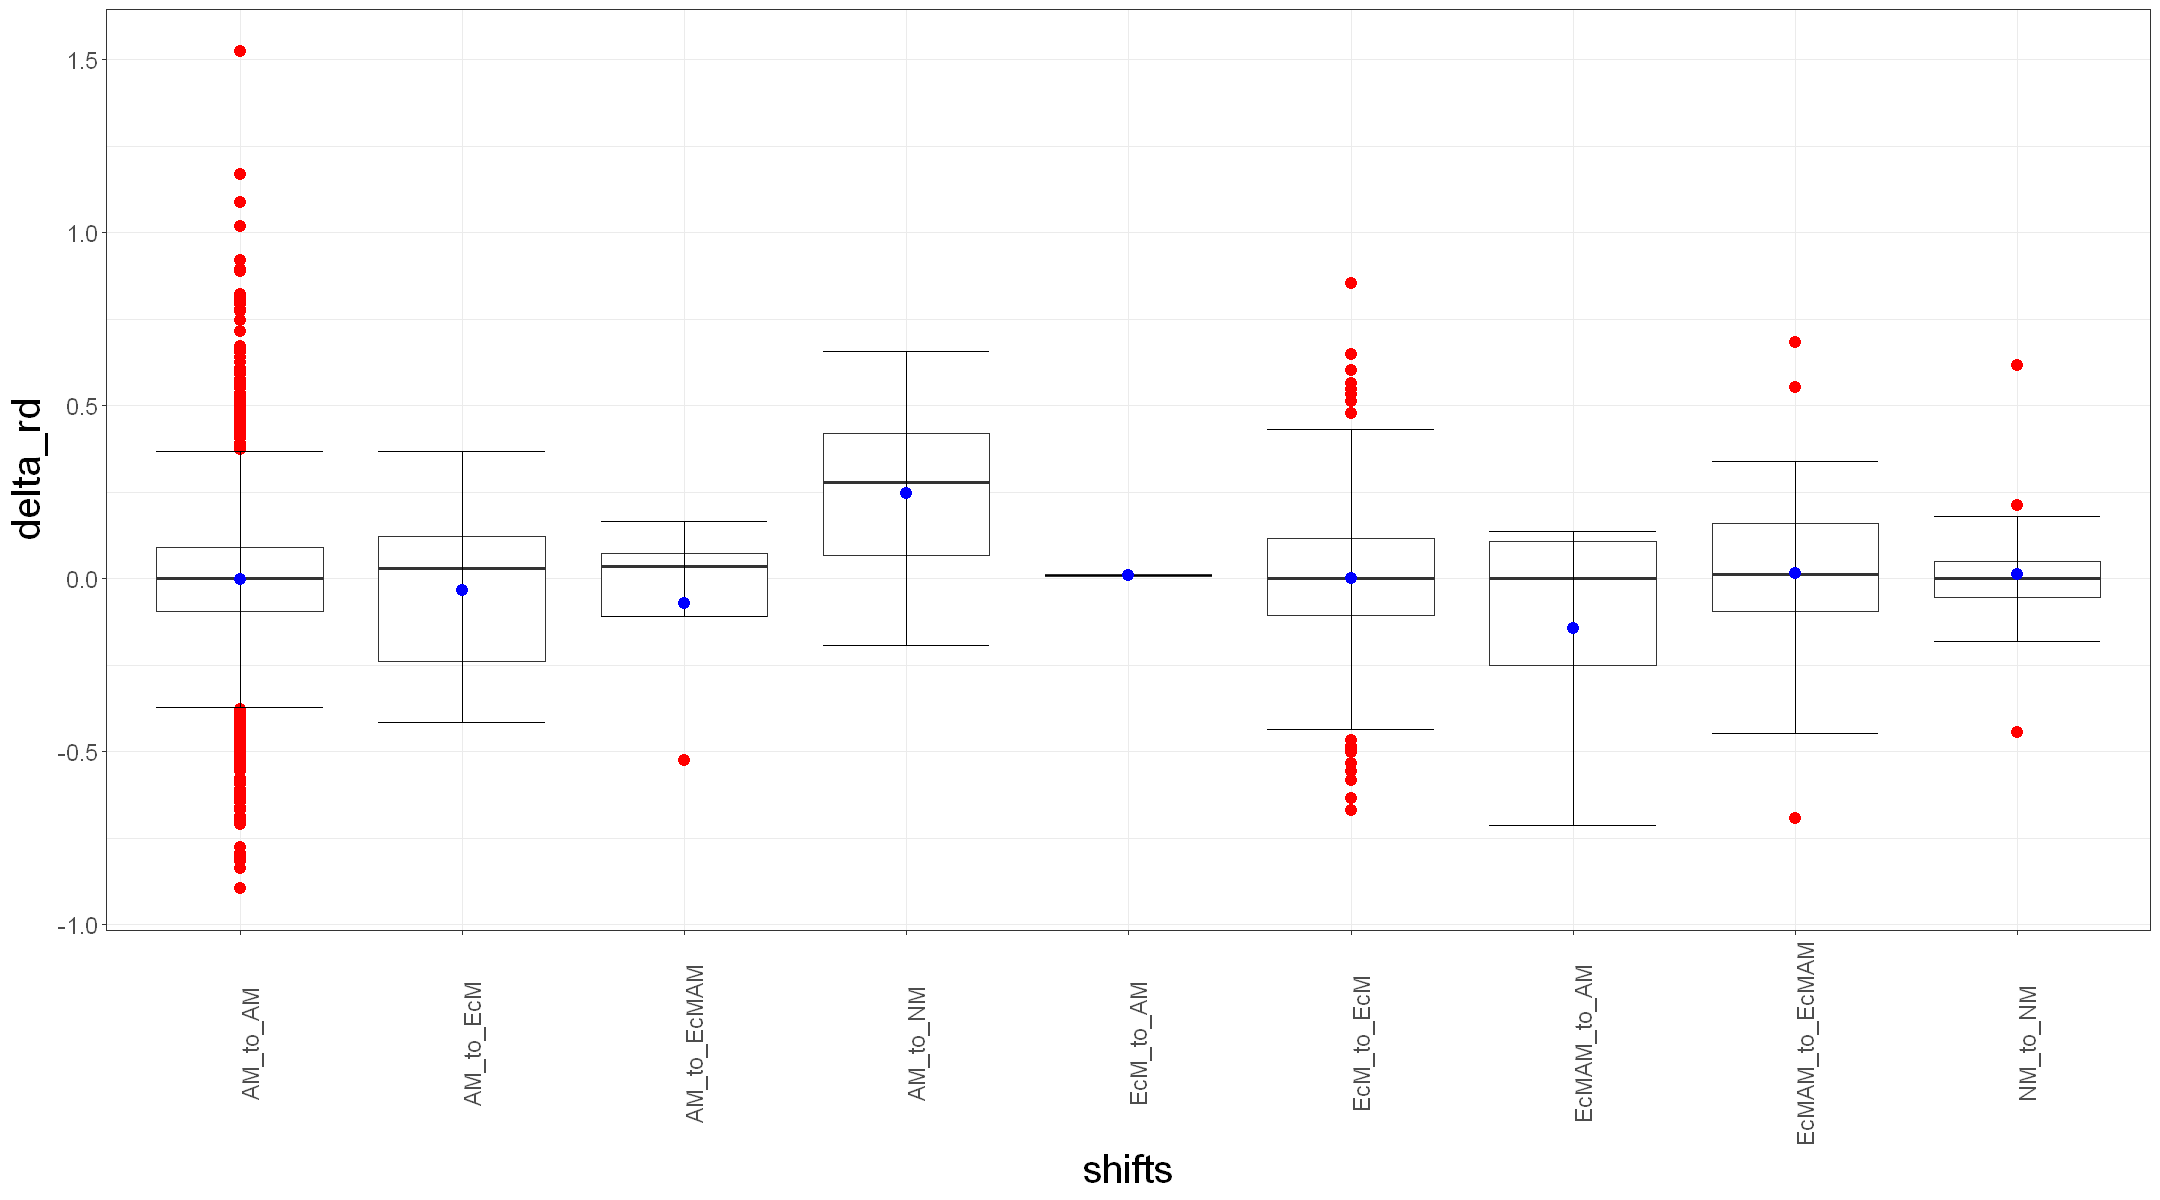

In [79]:
options(repr.plot.width = 18, repr.plot.height = 10)
ggplot2::ggplot(paired_changes994_4states, aes(x = shifts, y = delta_rd)) +
    geom_boxplot(outlier.color = "red", outlier.size = 3) +
    stat_boxplot(geom = "errorbar") +
    stat_summary(fun = mean, color = "blue", na.rm = FALSE, geom = "point", size = 3) +
    theme_bw() +
    theme(legend.position = "none", axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), axis.text = element_text(size = 14), axis.text.x = element_text(angle = 90))

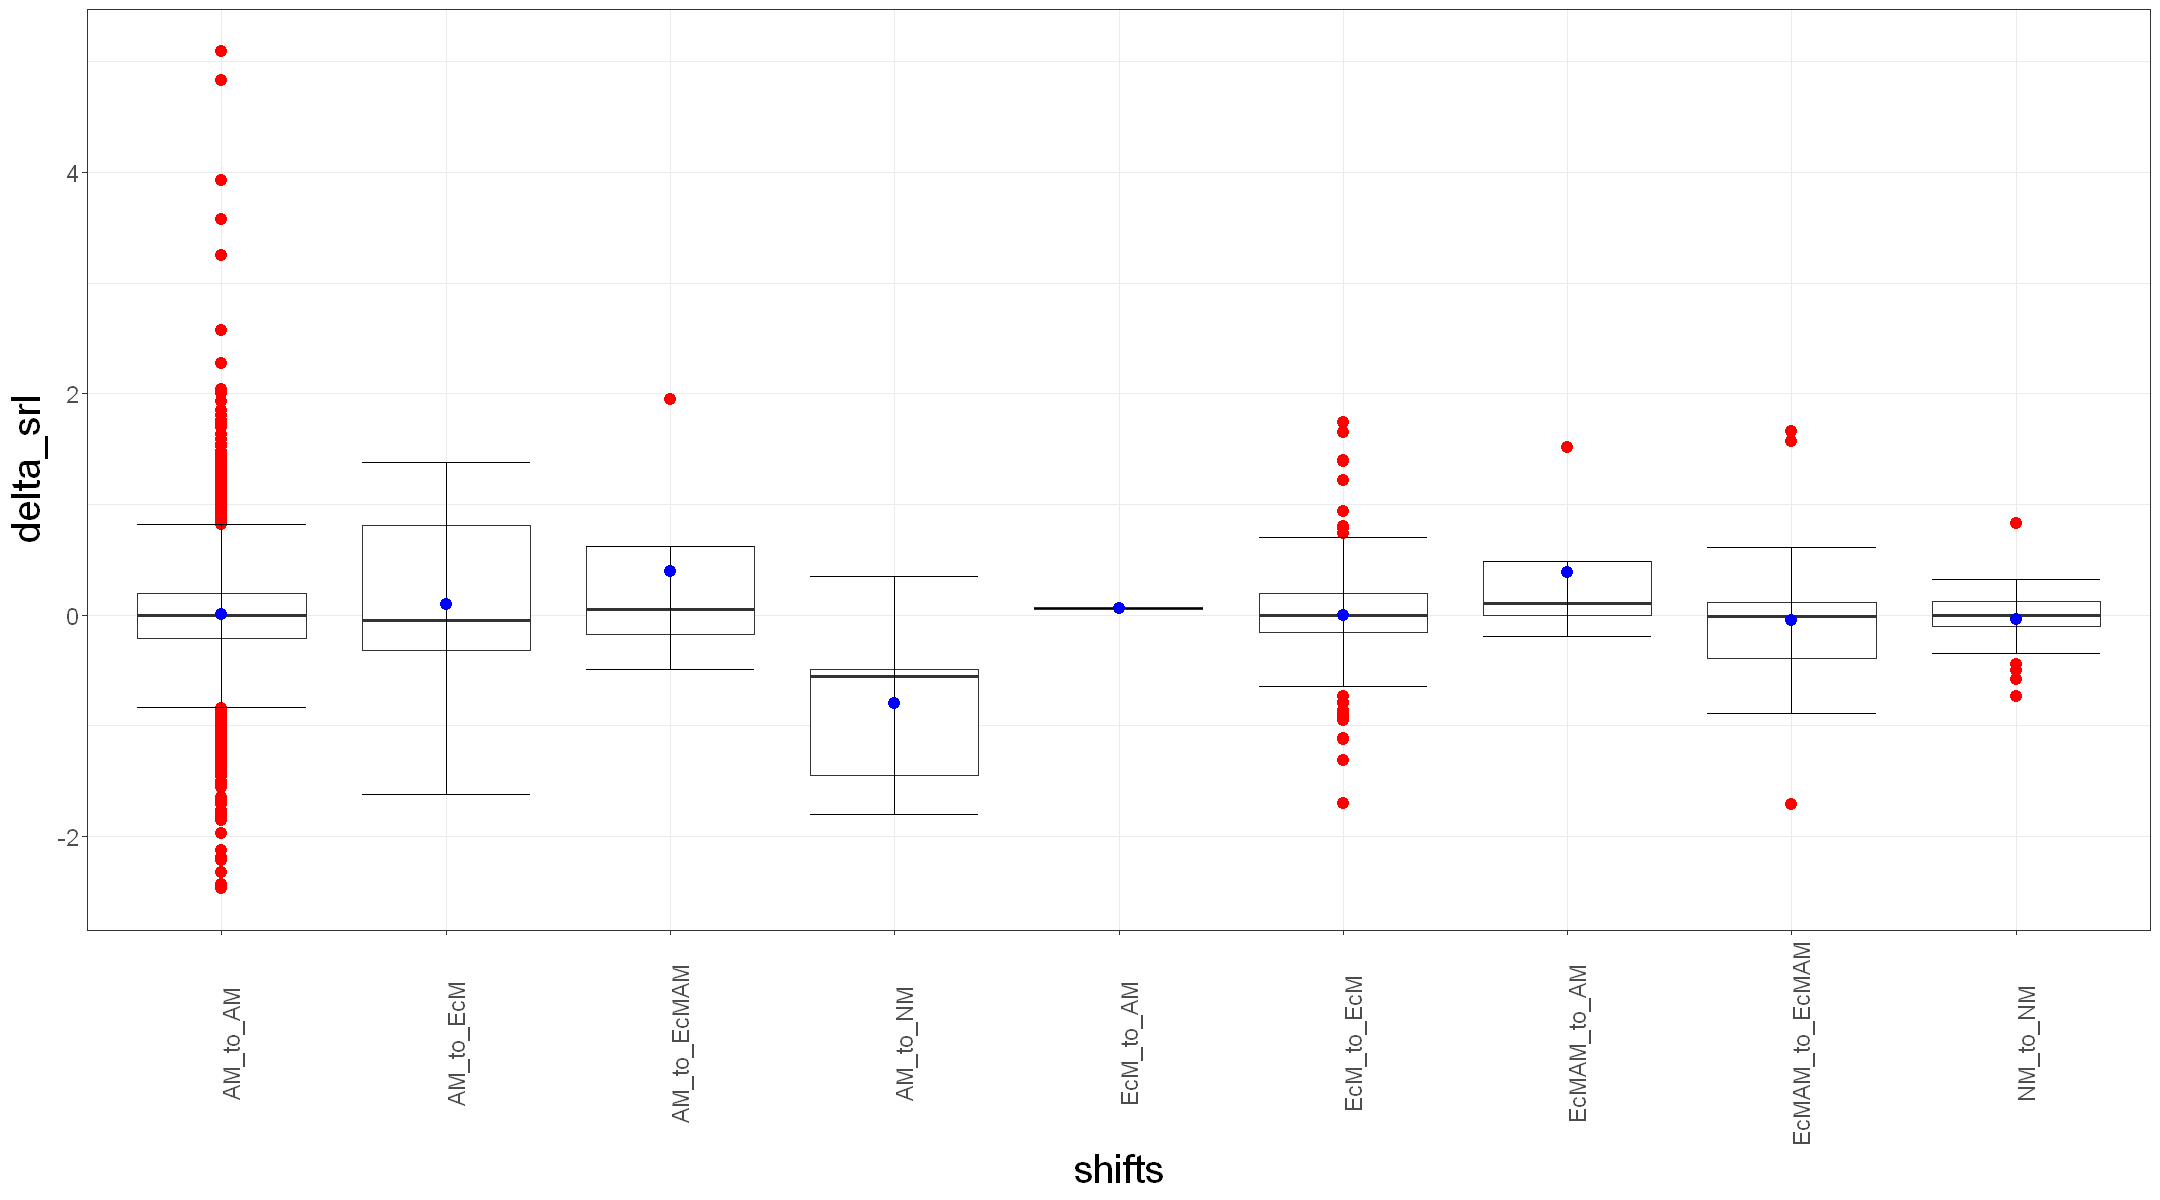

In [80]:
ggplot2::ggplot(paired_changes994_4states, aes(x = shifts, y = delta_srl)) +
    geom_boxplot(outlier.color = "red", outlier.size = 3) +
    stat_boxplot(geom = "errorbar") +
    stat_summary(fun = mean, color = "blue", na.rm = FALSE, geom = "point", size = 3) +
    theme_bw() +
    theme(legend.position = "none", axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), axis.text = element_text(size = 14), axis.text.x = element_text(angle = 90))

In [25]:
#----------------------------------------------------
# After removing OM and ErM
# With 5 states in the discrete trait
#----------------------------------------------------

phylo994 <- ape::read.tree("../parhOUwie/4states_994sp.tre") # same 994 species as the 4 states subset
# log transformed continuous trait values in named vectors
rd994 <- read.csv("../parhOUwie/gen_rec_5state_logged_994species_avgd_RD.csv")
rd994 <- setNames(rd994$RD, nm = rd994$binominal)

srl994 <- read.csv("../parhOUwie/gen_rec_5state_logged_994species_avgd_SRL.csv")
srl994 <- setNames(srl994$SRL, nm = srl994$binominal)

states994sp5 <- read.csv("../parhOUwie/gen_rec_5state_logged_994species_avgd_SRL.csv")[, c("binominal", "state")]

stopifnot(all(phylo994$tip.label==names(rd994)))
stopifnot(all(phylo994$tip.label==names(srl994)))

In [ ]:
load("../rdata/IndependentACEs994sp5states.RData")

In [27]:
ace_states_994sp_5states_corhmm


Fit
      -lnL      AIC    AICc Rate.cat ntax
 -221.3774 482.7547 483.618        1  994

Legend
      1       2       3       4       5 
   "AM"   "EcM" "EcMAM"    "NM"  "NMAM" 

Rates
             (1,R1)       (2,R1)       (3,R1)     (4,R1)       (5,R1)
(1,R1)           NA 0.0002016826 0.0002169061 2.2212e-04 0.0007897841
(2,R1) 0.0007754433           NA 0.0000000010 1.0000e-09 0.0000000010
(3,R1) 0.0142964490 0.0000000010           NA 1.0000e-09 0.0000000010
(4,R1) 0.0006251233 0.0000000010 0.0000000010         NA 0.0000000010
(5,R1) 0.0011460477 0.0007783133 0.0000000010 1.0000e-09           NA

Arrived at a reliable solution 

In [28]:
CORHMM_5STATES_LEGEND <- c("AM", "EcM", "EcMAM", "NM", "NMAM")

paired_changes994_5states <- paired_dc_changes(phylogeny = phylo994, rdextant = rd994, srlextant = srl994, discextant = setNames(states994sp5$state, nm = states994sp5$binominal),
                                               rdinternodes = ace_rd_994sp_5states_fastanc$ace, srlinternodes = ace_srl_994sp_5states_fastanc$ace, discprobinternodes = ace_states_994sp_5states_corhmm$states,
                                               discstates = CORHMM_5STATES_LEGEND)

In [36]:
as.data.frame(lapply(split(paired_changes994_5states, ~shifts), FUN = function(df) { c(mean(df$delta_rd), sd(df$delta_rd)) }), row.names = c("mean", "std")) # RD

,AM_to_AM,AM_to_EcM,AM_to_EcMAM,AM_to_NM,AM_to_NMAM,EcM_to_AM,EcM_to_EcM,EcMAM_to_AM,EcMAM_to_EcMAM,NM_to_NM,NMAM_to_AM,NMAM_to_EcM,NMAM_to_NMAM
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
mean,-0.0018075,0.001973271,-0.0723004,0.2467644,-0.001740675,0.008423744,0.001872745,-0.1436264,0.01517788,0.01118469,-0.03364491,-0.2591568,0.01940868
std,0.2262887,0.277638781,0.3086487,0.3055466,0.295368620,NA,0.237617186,0.3934269,0.25268553,0.17757961,NA,NA,0.26417415


In [40]:
as.data.frame(lapply(split(paired_changes994_5states, ~shifts), FUN = function(df) { c(mean(df$delta_srl), sd(df$delta_srl)) }), row.names = c("mean", "std")) # SRL

,AM_to_AM,AM_to_EcM,AM_to_EcMAM,AM_to_NM,AM_to_NMAM,EcM_to_AM,EcM_to_EcM,EcMAM_to_AM,EcMAM_to_EcMAM,NM_to_NM,NMAM_to_AM,NMAM_to_EcM,NMAM_to_NMAM
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
mean,0.006330641,-0.02756682,0.3919711,-0.7968144,-0.08598534,0.0599787,-0.002317954,0.3826653,-0.05082623,-0.03709043,-0.08853987,0.8645916,-0.05688183
std,0.571297171,1.03539693,1.0756014,0.8262253,0.92394157,NA,0.450227383,0.7697979,0.55379618,0.31751548,NA,NA,1.00015503


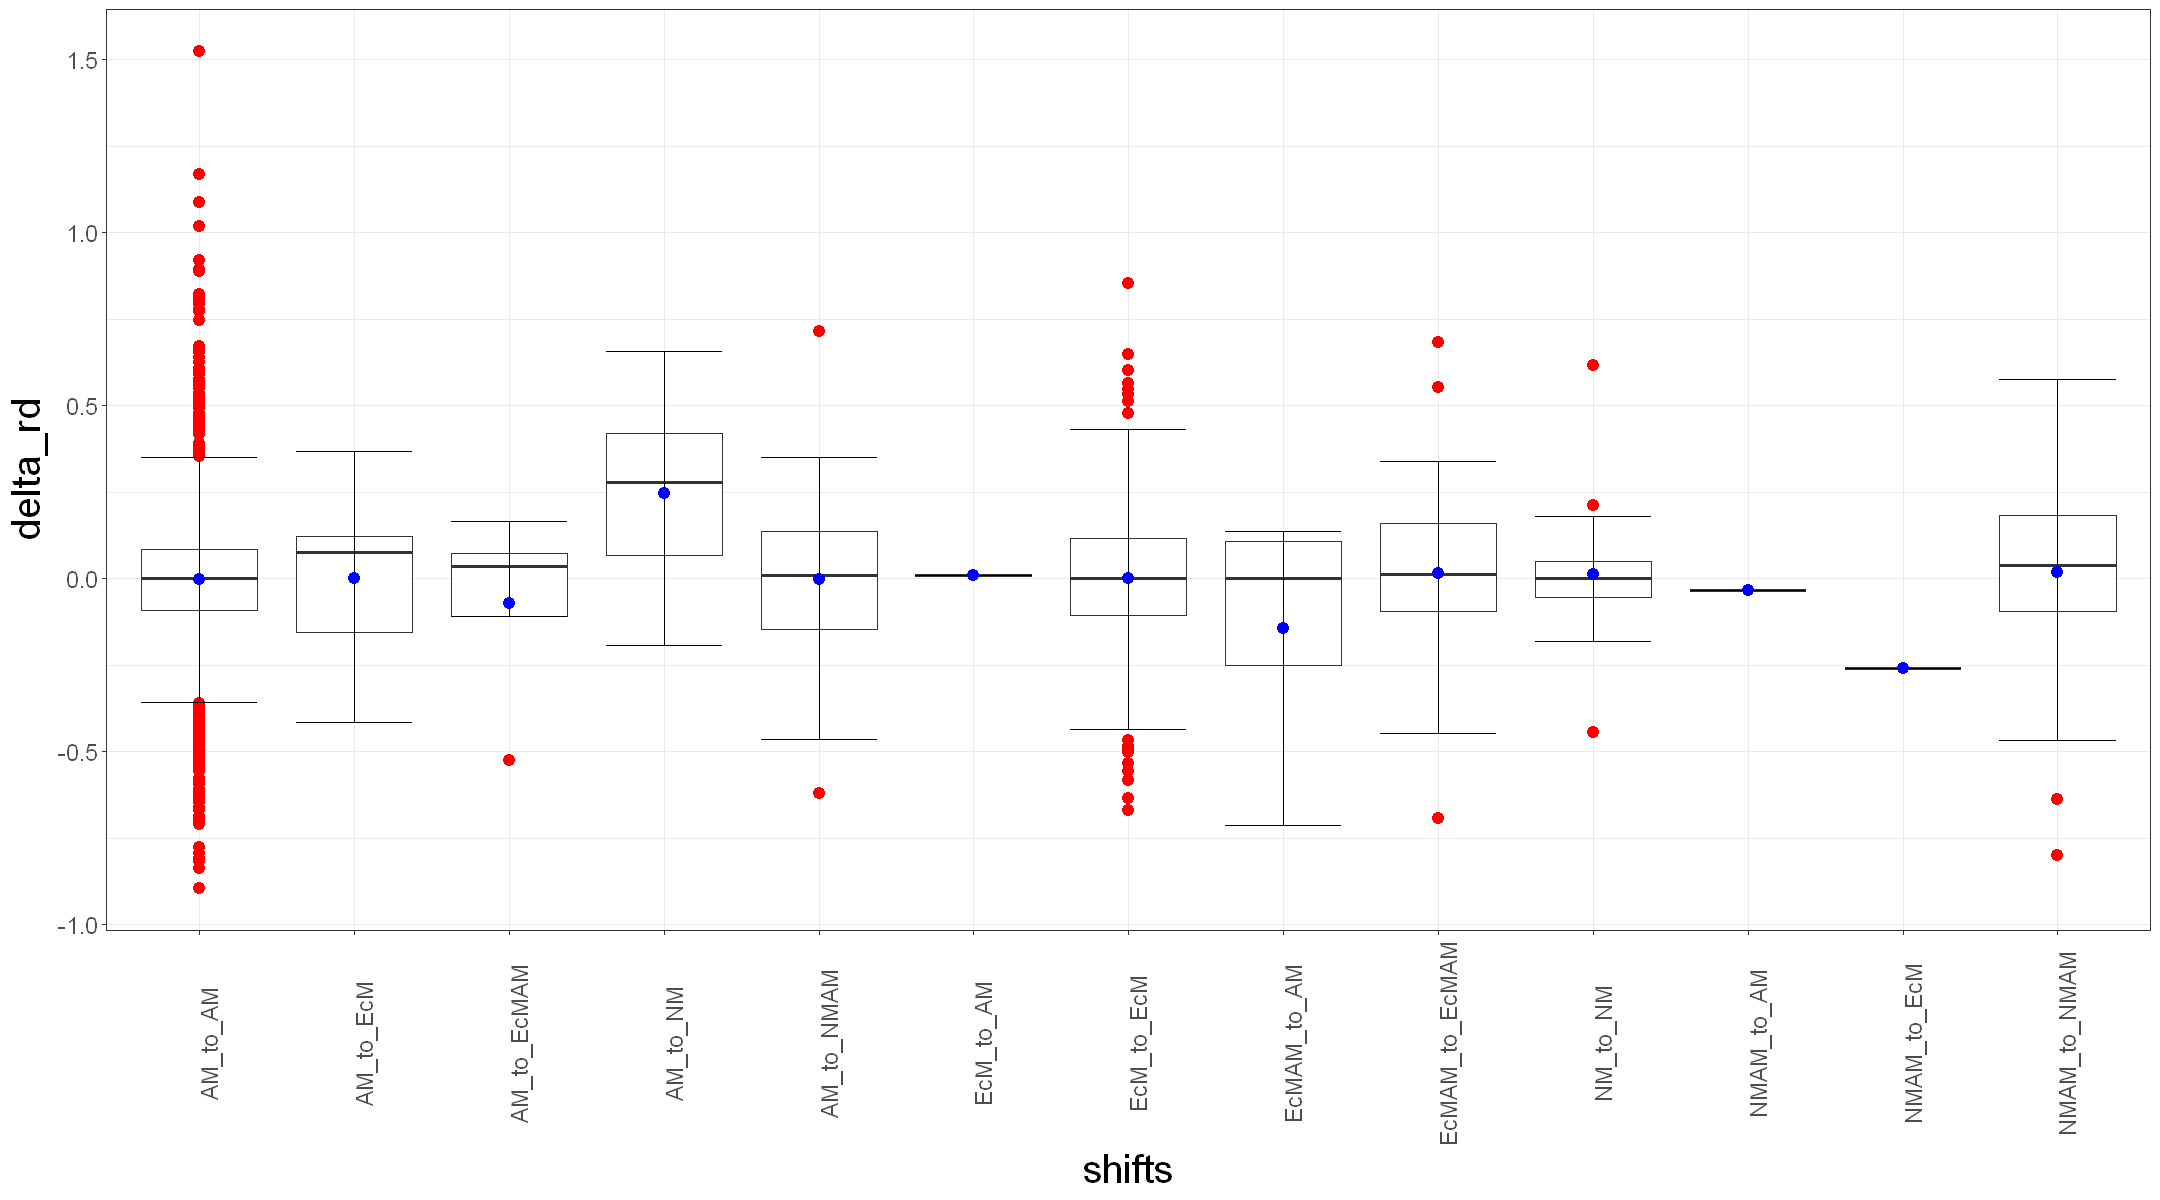

In [61]:
options(repr.plot.width = 18, repr.plot.height = 10)
ggplot2::ggplot(paired_changes994_5states, aes(x = shifts, y = delta_rd)) +
    geom_boxplot(outlier.color = "red", outlier.size = 3) +
    stat_boxplot(geom = "errorbar") +    
    stat_summary(fun = mean, color = "blue", na.rm = FALSE, geom = "point", size = 3) +
    theme_bw() +
    theme(legend.position = "none", axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), axis.text = element_text(size = 14), axis.text.x = element_text(angle = 90))

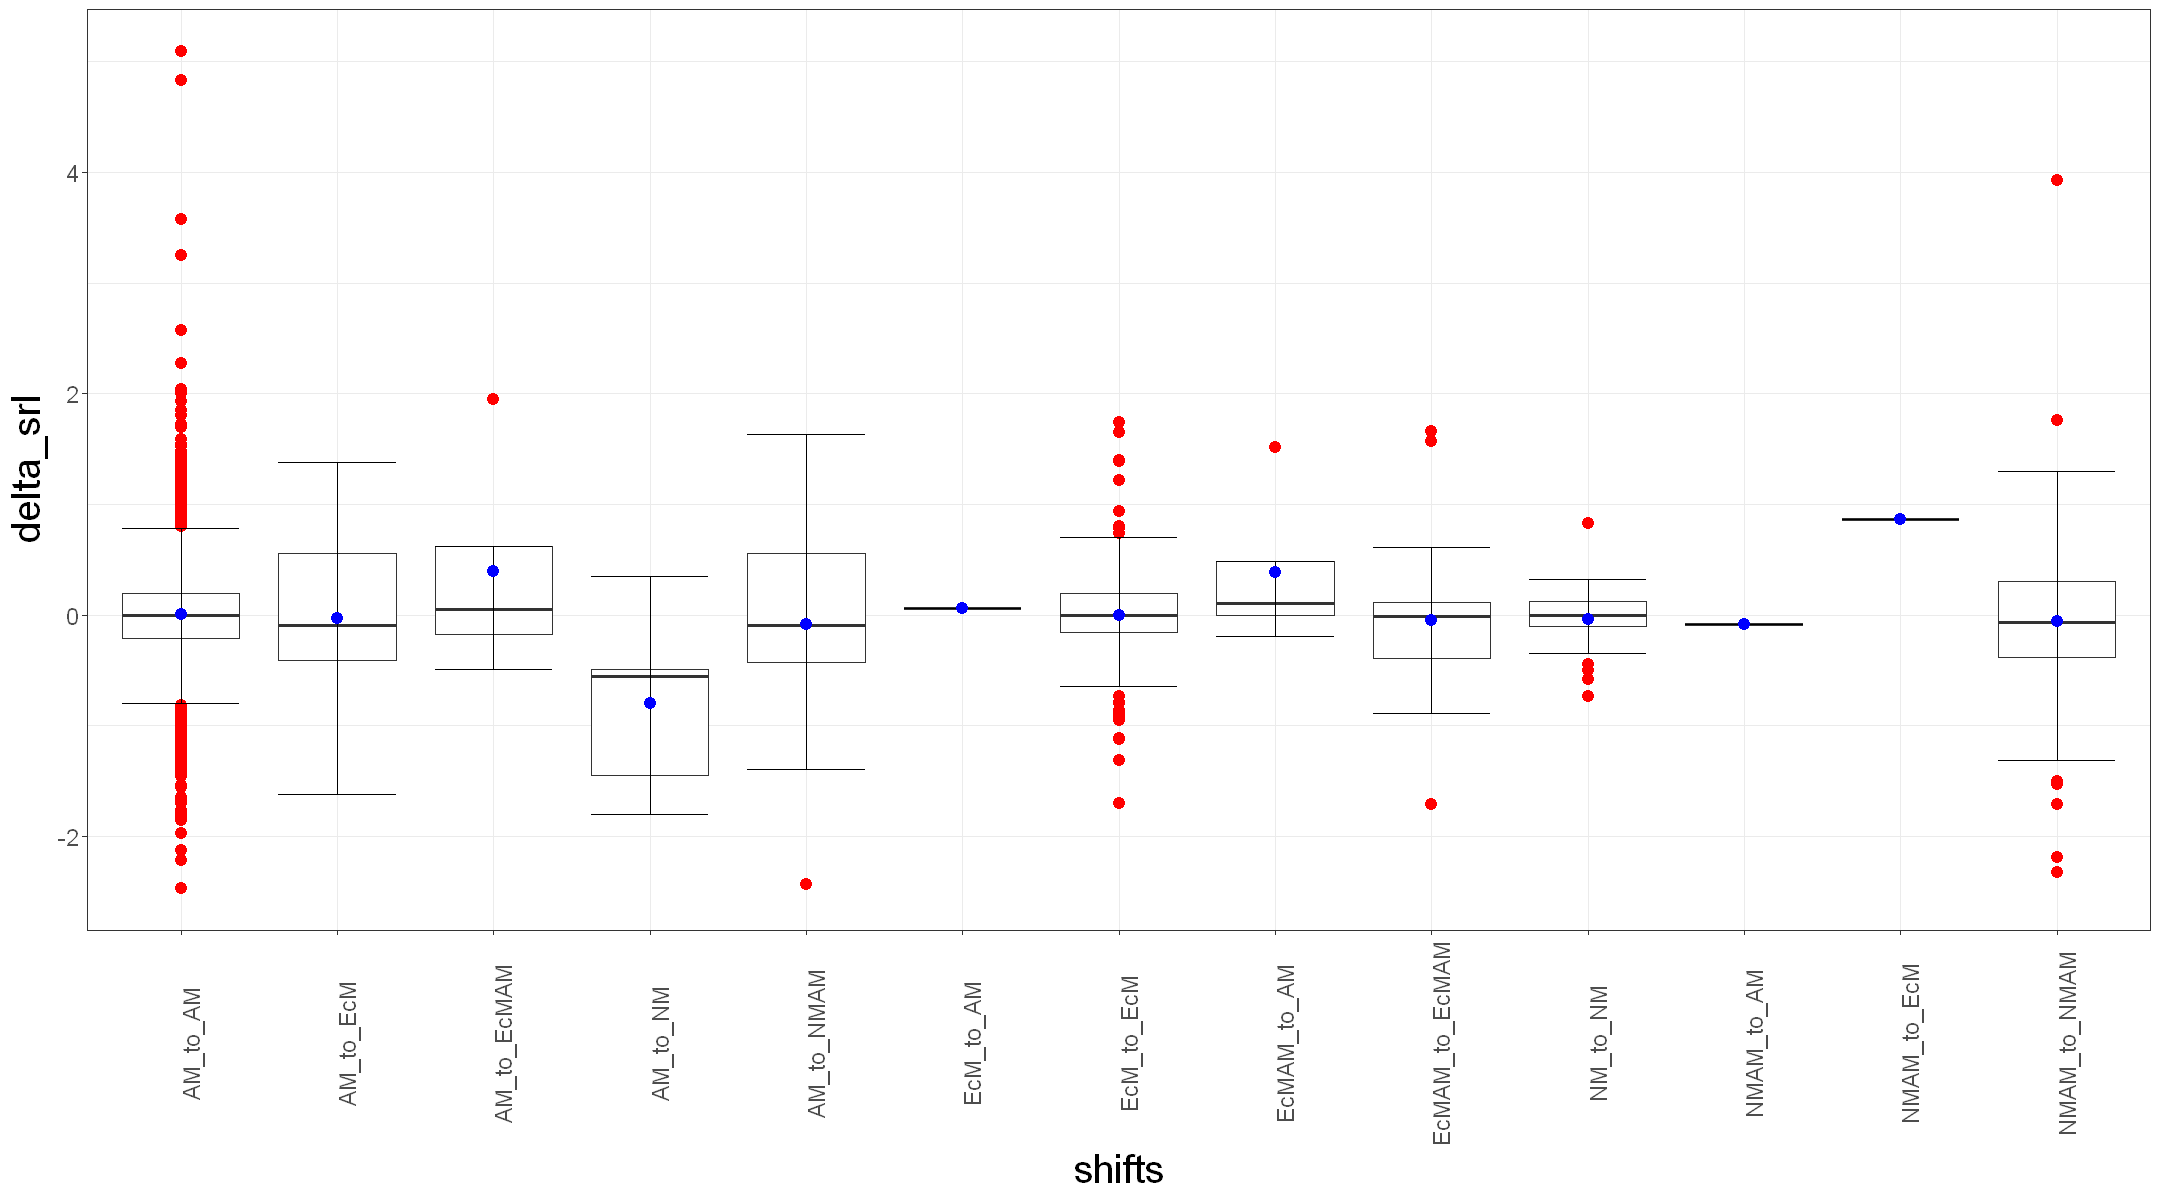

In [64]:
ggplot2::ggplot(paired_changes994_5states, aes(x = shifts, y = delta_srl)) +
    geom_boxplot(outlier.color = "red", outlier.size = 3) +
    stat_boxplot(geom = "errorbar") +
    stat_summary(fun = mean, color = "blue", na.rm = FALSE, geom = "point", size = 3) +
    theme_bw() +
    theme(legend.position = "none", axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), axis.text = element_text(size = 14), axis.text.x = element_text(angle = 90))